In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys, os
import matplotlib.pyplot as plt

In [2]:
sys.path.append(os.path.abspath("../.."))
sys.path

['C:\\Users\\Gaurav Garg\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip',
 'C:\\Users\\Gaurav Garg\\AppData\\Local\\Programs\\Python\\Python313\\DLLs',
 'C:\\Users\\Gaurav Garg\\AppData\\Local\\Programs\\Python\\Python313\\Lib',
 'C:\\Users\\Gaurav Garg\\AppData\\Local\\Programs\\Python\\Python313',
 '',
 'C:\\Users\\Gaurav Garg\\AppData\\Roaming\\Python\\Python313\\site-packages',
 'C:\\Users\\Gaurav Garg\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages',
 'c:\\Users\\Gaurav Garg\\OneDrive\\Desktop\\churn-prediction-project']

In [3]:
from src import utils

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv('../../data/raw/emails.csv')

C:\Users\Gaurav Garg\AppData\Local\Temp\ipykernel_30280\496971227.py:1: DtypeWarning: Columns (0: crm_agent_chase_count, 1: crm_auto_renewal_status) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/raw/emails.csv')


In [6]:
df.head()

,Co_Ref,Time_to_Renewal,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,crm_dts_or_ssip_mentioned,crm_customer_payment_intention,crm_competitors_mentioned,crm_membership_level,crm_platform_issues_raised,crm_agent_chased_contractor,crm_agent_chase_count,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,year
0,KG5766,pre_renewal,Not Discussed,Not Discussed,Not Discussed,Yes,No,Yes,Neutral,50,No,No,No,Not Discussed,No,Yes,1,Not Discussed,Yes,0,No,No,Yes,Yes,No,Yes,2025
1,EJ1532,14_out,Not Discussed,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Not Discussed,No,Not Discussed,No,Accredited,No,Yes,1,Not Discussed,Not Discussed,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
2,AA4063,prior_year,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Neutral,50,No,Yes,No,Accredited,No,No,0,Not Discussed,No,0,No,No,Yes,Yes,Yes,Not Discussed,2025
3,JY9888,prior_year,No,No,Not Discussed,Yes,No,Yes,Satisfied,80,Yes,Yes,No,Accredited,Yes,Yes,3,Not Discussed,Yes,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
4,WO6689,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Satisfied,80,No,Yes,No,Accredited,No,No,0,No,No,0,No,No,Yes,Yes,No,Not Discussed,2026


In [7]:
df.shape

(123389, 27)

### convert column names to snakecase

In [8]:
df = utils.convert_columns_to_snake_case(df)

## Detecting duplicate columns

In [9]:
duplicates = []
cols = df.columns.tolist()

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if df[c1].astype(str).equals(df[c2].astype(str)):
            duplicates.append((c1, c2))

for c1, c2 in duplicates:
    print(f"{c1}  ==  {c2}")

### Identifying numerical and categorical data

In [10]:
df.dtypes

co_ref                                     str
time_to_renewal                            str
crm_accreditation_completed                str
crm_timely_completion                      str
crm_progress_towards_accreditation         str
crm_delays_in_accreditation                str
crm_contractor_suggested_leave             str
crm_contractor_engagement                  str
crm_contractor_sentiment                   str
crm_contractor_sentiment_score             str
crm_dts_or_ssip_mentioned                  str
crm_customer_payment_intention             str
crm_competitors_mentioned                  str
crm_membership_level                       str
crm_platform_issues_raised                 str
crm_agent_chased_contractor                str
crm_agent_chase_count                   object
crm_accreditation_issues                   str
crm_membership_overdue                     str
crm_auto_renewal_status                 object
crm_dissatisified_with_renewal_price       str
crm_customer_

In [11]:
df.nunique()

co_ref                                  37964
time_to_renewal                             4
crm_accreditation_completed                 3
crm_timely_completion                       3
crm_progress_towards_accreditation          3
crm_delays_in_accreditation                18
crm_contractor_suggested_leave              3
crm_contractor_engagement                  28
crm_contractor_sentiment                   12
crm_contractor_sentiment_score             52
crm_dts_or_ssip_mentioned                   9
crm_customer_payment_intention              6
crm_competitors_mentioned                   5
crm_membership_level                       57
crm_platform_issues_raised                  3
crm_agent_chased_contractor                 3
crm_agent_chase_count                     114
crm_accreditation_issues                    3
crm_membership_overdue                     53
crm_auto_renewal_status                    15
crm_dissatisified_with_renewal_price        6
crm_customer_complained           

In [12]:
df['time_to_renewal'].value_counts()

time_to_renewal
prior_year     40022
14_out         32493
45_out         28008
pre_renewal    22866
Name: count, dtype: int64

In [13]:
df['time_to_renewal'].isnull().sum()

np.int64(0)

### in column 'time_to_renewal' we can find pre_renewal category and filter out data which is relevant to our use case

In [14]:
df = df[df['time_to_renewal'] == 'pre_renewal']

In [15]:
df.head()

,co_ref,time_to_renewal,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,crm_dts_or_ssip_mentioned,crm_customer_payment_intention,crm_competitors_mentioned,crm_membership_level,crm_platform_issues_raised,crm_agent_chased_contractor,crm_agent_chase_count,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,year
0,KG5766,pre_renewal,Not Discussed,Not Discussed,Not Discussed,Yes,No,Yes,Neutral,50,No,No,No,Not Discussed,No,Yes,1,Not Discussed,Yes,0,No,No,Yes,Yes,No,Yes,2025
4,WO6689,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Satisfied,80,No,Yes,No,Accredited,No,No,0,No,No,0,No,No,Yes,Yes,No,Not Discussed,2026
6,SB4066,pre_renewal,Not Discussed,Not Discussed,Not Discussed,Yes,No,Yes,Neutral,50,No,Yes,Not Discussed,Not Discussed,Not Discussed,Yes,3,Not Discussed,Yes,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2026
7,YK0304,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Yes,No,0,Not Discussed,Not Discussed,0,Not Discussed,No,Yes,Yes,Yes,Not Discussed,2025
8,HH3570,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Satisfied,80,Yes,Yes,No,Accredited,No,Yes,1,Not Discussed,Yes,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025


In [16]:
df.shape

(22866, 27)

### check for duplicates

In [17]:
df.duplicated().sum()

np.int64(0)

### Most of the columns contain categorical data and mixed data such as numerical and string. 'Not Discussed' is used in place of nulls

In [18]:
for col in df.columns:
    print(df[col].value_counts())
    print('nulls: ', df[col].isnull().sum())
    print('-' * 100)


co_ref
QE7976    3
JM8979    3
BR5192    2
BQ8500    2
CP6040    2
         ..
ZZ9369    1
WO3900    1
JQ2250    1
RQ3555    1
TD7281    1
Name: count, Length: 21362, dtype: int64
nulls:  0
----------------------------------------------------------------------------------------------------
time_to_renewal
pre_renewal    22866
Name: count, dtype: int64
nulls:  0
----------------------------------------------------------------------------------------------------
crm_accreditation_completed
Not Discussed    10722
No                6742
Yes               2247
Name: count, dtype: int64
nulls:  3155
----------------------------------------------------------------------------------------------------
crm_timely_completion
Not Discussed    17824
No                1474
Yes                413
Name: count, dtype: int64
nulls:  3155
----------------------------------------------------------------------------------------------------
crm_progress_towards_accreditation
Not Discussed    13790
Yes      

In [19]:
df.dtypes

co_ref                                     str
time_to_renewal                            str
crm_accreditation_completed                str
crm_timely_completion                      str
crm_progress_towards_accreditation         str
crm_delays_in_accreditation                str
crm_contractor_suggested_leave             str
crm_contractor_engagement                  str
crm_contractor_sentiment                   str
crm_contractor_sentiment_score             str
crm_dts_or_ssip_mentioned                  str
crm_customer_payment_intention             str
crm_competitors_mentioned                  str
crm_membership_level                       str
crm_platform_issues_raised                 str
crm_agent_chased_contractor                str
crm_agent_chase_count                   object
crm_accreditation_issues                   str
crm_membership_overdue                     str
crm_auto_renewal_status                 object
crm_dissatisified_with_renewal_price       str
crm_customer_

## handle numerical columns

In [20]:
numerical_cols = ['crm_contractor_sentiment_score', 'crm_agent_chase_count', 'crm_auto_renewal_status']

In [21]:
df[numerical_cols].dtypes

crm_contractor_sentiment_score       str
crm_agent_chase_count             object
crm_auto_renewal_status           object
dtype: object

In [22]:
for col in numerical_cols:
    df[col] = pd.to_numeric(
        df[col], errors='coerce'
    )

In [23]:
for col in numerical_cols:
    print(col)
    print(df[col].unique())
    print('-' * 100)

crm_contractor_sentiment_score
[ 50.   80.    nan  40.   20.   30.   60.   84.    0.   90.  100.   16.
  91.   48.   55.   70.   31.   98.   25.5  96. ]
----------------------------------------------------------------------------------------------------
crm_agent_chase_count
[ 1.  0.  3.  2.  5.  6. nan  4. 11. 10. 13.  7.  8.]
----------------------------------------------------------------------------------------------------
crm_auto_renewal_status
[ 0.  2. nan  1.]
----------------------------------------------------------------------------------------------------


### cleaning crm_auto_renewal_status (a categorical column, already encoded, filling nulls)

In [24]:
print(df['crm_auto_renewal_status'].isnull().sum())

1522


In [25]:
df['crm_auto_renewal_status'].value_counts()

crm_auto_renewal_status
0.0    19978
2.0     1226
1.0      140
Name: count, dtype: int64

In [26]:
# fill with mode (most frequent)
df['crm_auto_renewal_status'] = df['crm_auto_renewal_status'].fillna(0)

In [27]:
df['crm_auto_renewal_status'].value_counts()

crm_auto_renewal_status
0.0    21500
2.0     1226
1.0      140
Name: count, dtype: int64

### cleaning crm_contractor_sentiment_score

In [28]:
df['crm_contractor_sentiment_score'].value_counts()

crm_contractor_sentiment_score
50.0     8609
80.0     1449
20.0      811
90.0      577
0.0       282
30.0      238
100.0     225
40.0      168
60.0        1
84.0        1
16.0        1
91.0        1
48.0        1
55.0        1
70.0        1
31.0        1
98.0        1
25.5        1
96.0        1
Name: count, dtype: int64

In [29]:
df['crm_contractor_sentiment_score'].isnull().sum()

np.int64(10496)

In [30]:
print(df["crm_contractor_sentiment_score"].isna().mean() * 100, '%')

45.90221289250416 %


In [31]:
print(df['crm_contractor_sentiment_score'].skew())

0.1373348999690788


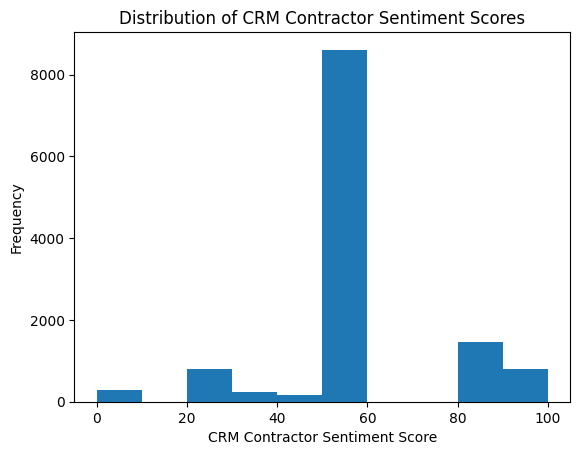

In [32]:
plt.hist(df['crm_contractor_sentiment_score'], bins=10)
plt.xlabel('CRM Contractor Sentiment Score')
plt.ylabel('Frequency')
plt.title('Distribution of CRM Contractor Sentiment Scores')
plt.show()

### we cannot fill this directly with mean, median or mode as all of them will be 50 due to highest
This completely destroys the discriminative power of this feature.

In [33]:
df['crm_contractor_sentiment'].value_counts()

crm_contractor_sentiment
Neutral                                  8612
Not Discussed                            7337
Satisfied                                2254
Dissatisfied                             1503
Yes                                         3
Initially Dissatisfied, later Neutral       1
No                                          1
Name: count, dtype: int64

In [34]:
def clean_sentiment(val):
    if pd.isna(val):
        return "Unknown"
    
    val = str(val).lower().strip()
    
    # handle not discussed
    if "not" in val:
        return "Unknown"
    
    # handle mixed sentiment (very important)
    if "dissatisfied" in val and "neutral" in val:
        return "neutral"   # final state matters more
    
    # normal cases
    if "dissatisfied" in val:
        return "dissatisfied"
    elif "satisfied" in val:
        return "satisfied"
    
    
    return "neutral"

df['crm_contractor_sentiment'] = df['crm_contractor_sentiment'].apply(clean_sentiment)

In [35]:
df['crm_contractor_sentiment'].value_counts()

crm_contractor_sentiment
Unknown         10492
neutral          8617
satisfied        2254
dissatisfied     1503
Name: count, dtype: int64

we will add a missing indicator for null values and fill with -1 (outside 0-100 range), this helps model differentiate these values without compromizing on raws

In [36]:
# missing indicator
df["sentiment_score_missing"] = df["crm_contractor_sentiment_score"].isna().astype(int)

# Fill "Not Discussed" group with a DISTINCT sentinel value
# Use a value OUTSIDE the normal 0-100 range, like -1
# This tells the model "this is a different category"
df["crm_contractor_sentiment_score"] = df["crm_contractor_sentiment_score"].fillna(-1)


In [37]:
df.shape

(22866, 28)

In [38]:
print(df['crm_contractor_sentiment_score'].isnull().sum())

0


In [39]:
df['crm_contractor_sentiment_score'].value_counts()

crm_contractor_sentiment_score
-1.0      10496
 50.0      8609
 80.0      1449
 20.0       811
 90.0       577
 0.0        282
 30.0       238
 100.0      225
 40.0       168
 60.0         1
 84.0         1
 16.0         1
 91.0         1
 48.0         1
 55.0         1
 70.0         1
 31.0         1
 98.0         1
 25.5         1
 96.0         1
Name: count, dtype: int64

## crm_agent_chase_count

In [40]:
print(df['crm_agent_chase_count'].unique())

[ 1.  0.  3.  2.  5.  6. nan  4. 11. 10. 13.  7.  8.]


In [41]:
df['crm_agent_chase_count'].value_counts()

crm_agent_chase_count
0.0     8359
1.0     8125
2.0     3818
3.0      824
4.0      106
5.0       31
6.0        9
7.0        5
10.0       2
11.0       1
13.0       1
8.0        1
Name: count, dtype: int64

In [42]:
print(df['crm_agent_chase_count'].isnull().sum())

1584


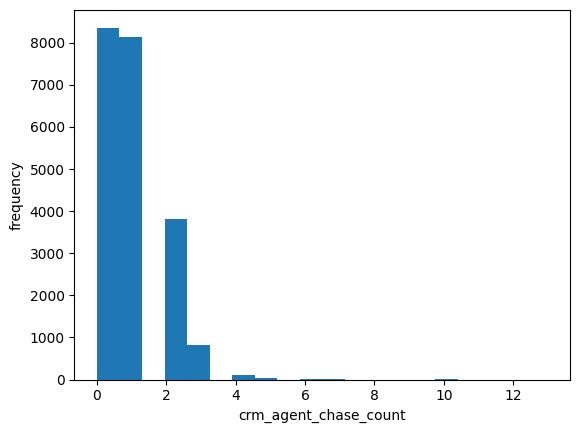

In [43]:
plt.hist(df['crm_agent_chase_count'], bins=20)
plt.xlabel('crm_agent_chase_count')
plt.ylabel('frequency')
plt.show()

In [44]:
df['crm_agent_chase_count'].skew()

np.float64(1.2204974752783757)

In [45]:
df['crm_agent_chase_count'].median()

np.float64(1.0)

In [46]:
# use median to fill
df['crm_agent_chase_count'] = df['crm_agent_chase_count'].fillna(
    df['crm_agent_chase_count'].median()
)

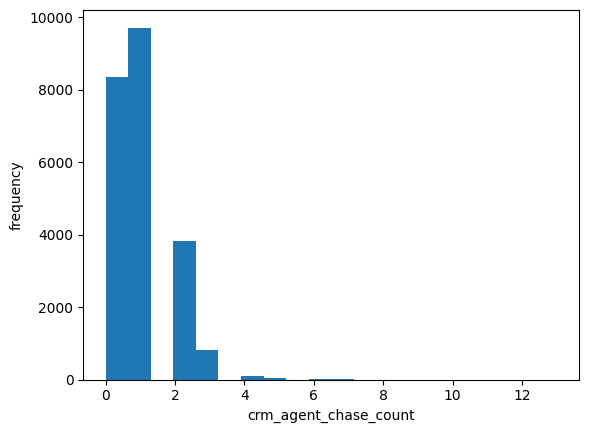

In [47]:
plt.hist(df['crm_agent_chase_count'], bins=20)
plt.xlabel('crm_agent_chase_count')
plt.ylabel('frequency')
plt.show()

### handling categorical features

In [48]:
for col in df.columns:
    print(df[col].value_counts())
    print(df[col].isnull().sum())

co_ref
QE7976    3
JM8979    3
BR5192    2
BQ8500    2
CP6040    2
         ..
ZZ9369    1
WO3900    1
JQ2250    1
RQ3555    1
TD7281    1
Name: count, Length: 21362, dtype: int64
0
time_to_renewal
pre_renewal    22866
Name: count, dtype: int64
0
crm_accreditation_completed
Not Discussed    10722
No                6742
Yes               2247
Name: count, dtype: int64
3155
crm_timely_completion
Not Discussed    17824
No                1474
Yes                413
Name: count, dtype: int64
3155
crm_progress_towards_accreditation
Not Discussed    13790
Yes               5343
No                 578
Name: count, dtype: int64
3155
crm_delays_in_accreditation
No                                                                                                                            14986
Yes                                                                                                                            4464
Not Discussed                                                               

In [49]:
categorical_cols = []

for col in df.columns:
    if col not in numerical_cols:
        categorical_cols.append(col)

## GROUP A: Clean columns — just fill NaN with "Unknown"

In [50]:
group_a_cols = [
    'crm_accreditation_completed',
    'crm_timely_completion',
    'crm_progress_towards_accreditation',
    'crm_contractor_suggested_leave',
    'crm_customer_payment_intention',
    'crm_competitors_mentioned',
    'crm_platform_issues_raised',
    'crm_agent_chased_contractor',
    'crm_accreditation_issues',
]

In [51]:
for col in group_a_cols:
    print(df[col].value_counts())
    print("nulls: ", df[col].isnull().sum())
    print('-' * 100)

crm_accreditation_completed
Not Discussed    10722
No                6742
Yes               2247
Name: count, dtype: int64
nulls:  3155
----------------------------------------------------------------------------------------------------
crm_timely_completion
Not Discussed    17824
No                1474
Yes                413
Name: count, dtype: int64
nulls:  3155
----------------------------------------------------------------------------------------------------
crm_progress_towards_accreditation
Not Discussed    13790
Yes               5343
No                 578
Name: count, dtype: int64
nulls:  3155
----------------------------------------------------------------------------------------------------
crm_contractor_suggested_leave
No               14480
Not Discussed     2649
Yes               2582
Name: count, dtype: int64
nulls:  3155
----------------------------------------------------------------------------------------------------
crm_customer_payment_intention
Not Discussed    

In [52]:
def clean_ternary_column(val, garbage_fallback="Unknown"):
    """
    Cleans a Yes/No/Not Discussed categorical column.

    Rules (in order):
      1. NaN → "Unknown"
      2. "Yes" / "No" / "Not Discussed" (exact match after strip) → kept as-is
      3. "Not applicable..." / "Not Applicable..." → "Not Discussed"
      4. "[Yes/No]" / "[Yes/No/Not Discussed]" → "Unknown"
      5. Anything else (garbage text, numbers) → garbage_fallback
    """
    if pd.isna(val):
        return "Unknown"

    val_clean = str(val).strip()

    # Rule 2: exact match for valid categories
    if val_clean in ("Yes", "No", "Not Discussed"):
        return val_clean

    # Rule 3: "Not applicable" variations → "Not Discussed"
    val_lower = val_clean.lower()
    if val_lower.startswith("not applicable"):
        return "Not Discussed"

    # Rule 4: ambiguous bracketed placeholders → "Unknown"
    if val_clean.startswith("["):
        return "Unknown"

    # Rule 5: everything else → column-specific fallback
    return garbage_fallback


In [53]:
for col in group_a_cols:
    df[col] = df[col].apply(clean_ternary_column)

In [54]:
for col in group_a_cols:
    print(df[col].value_counts())
    print("nulls: ", df[col].isnull().sum())
    print('-' * 100)

crm_accreditation_completed
Not Discussed    10722
No                6742
Unknown           3155
Yes               2247
Name: count, dtype: int64
nulls:  0
----------------------------------------------------------------------------------------------------
crm_timely_completion
Not Discussed    17824
Unknown           3155
No                1474
Yes                413
Name: count, dtype: int64
nulls:  0
----------------------------------------------------------------------------------------------------
crm_progress_towards_accreditation
Not Discussed    13790
Yes               5343
Unknown           3155
No                 578
Name: count, dtype: int64
nulls:  0
----------------------------------------------------------------------------------------------------
crm_contractor_suggested_leave
No               14480
Unknown           3155
Not Discussed     2649
Yes               2582
Name: count, dtype: int64
nulls:  0
---------------------------------------------------------------------

### GROUP B: Columns with garbage text to clean

In [55]:
group_b_cols = [
    'crm_delays_in_accreditation',
    'crm_contractor_engagement',
    'crm_dts_or_ssip_mentioned',
    'crm_membership_overdue',
    'crm_dissatisified_with_renewal_price',
    'crm_customer_complained',
    'crm_refund_mentioned',
    'crm_negative_customer_experience',
    'crm_dissatisfaction_with_support',
    'crm_financial_hardship_mentioned'
]

In [56]:
for col in group_b_cols:
    print(df[col].value_counts())
    print(df[col].isnull().sum())
    print('_'*100)

crm_delays_in_accreditation
No                                                                                                                            14986
Yes                                                                                                                            4464
Not Discussed                                                                                                                   259
Not Discussed but potentially yes as the customer is trying to contact Ian and was told he may be in later or the next day        1
Not Discussed but potentially yes due to lack of progress                                                                         1
Name: count, dtype: int64
3155
____________________________________________________________________________________________________
crm_contractor_engagement
Yes                                                                                                12361
No                                               

In [57]:
group_b_config = {
    'crm_delays_in_accreditation':            'Yes',
    'crm_contractor_engagement':              'No',
    'crm_dts_or_ssip_mentioned':              'No',
    'crm_membership_overdue':                 'Yes',
    'crm_dissatisified_with_renewal_price':   'No',
    'crm_customer_complained':                'No',
    'crm_refund_mentioned':                   'No',
    'crm_negative_customer_experience':       'Yes',
    'crm_dissatisfaction_with_support':       'Yes',
    'crm_financial_hardship_mentioned':       'Yes',
}

for col, fallback in group_b_config.items():
    df[col] = df[col].apply(lambda v, fb=fallback: clean_ternary_column(v, garbage_fallback=fb))


In [58]:
for col in group_b_cols:
    print(df[col].value_counts())
    print(df[col].isnull().sum())
    print('_'*100)

crm_delays_in_accreditation
No               14986
Yes               4466
Unknown           3155
Not Discussed      259
Name: count, dtype: int64
0
____________________________________________________________________________________________________
crm_contractor_engagement
Yes              12361
No                7346
Unknown           3155
Not Discussed        4
Name: count, dtype: int64
0
____________________________________________________________________________________________________
crm_dts_or_ssip_mentioned
No               15481
Yes               4229
Unknown           3155
Not Discussed        1
Name: count, dtype: int64
0
____________________________________________________________________________________________________
crm_membership_overdue
Yes              9465
Not Discussed    7875
No               4008
Unknown          1518
Name: count, dtype: int64
0
____________________________________________________________________________________________________
crm_dissatisified

0
____________________________________________________________________________________________________
crm_dissatisfaction_with_support
No               11628
Not Discussed     8084
Unknown           1631
Yes               1523
Name: count, dtype: int64
0
____________________________________________________________________________________________________
crm_financial_hardship_mentioned
Not Discussed    15609
No                4305
Unknown           1631
Yes               1321
Name: count, dtype: int64
0
____________________________________________________________________________________________________


### GROUP C: crm_membership_level — consolidate categories

In [59]:
df['crm_membership_level'].value_counts()

crm_membership_level
Not Discussed                8374
Accredited                   7153
In progress                  5621
Members only                  101
Not Accredited                 70
Standard                        9
Membership (Standard)           5
Standard membership             3
Gold                            2
Standard membership level       2
Premier services                1
Premier Band C2                 1
Premier Band B                  1
Silver                          1
Premier package                 1
Accredited (Gold level)         1
Prem                            1
Express membership level        1
Name: count, dtype: int64

In [60]:
df['crm_membership_level'].isnull().sum()

np.int64(1518)

In [61]:
def clean_membership_level(val):
    """
    Consolidate crm_membership_level into clean categories.
    NaN → "Unknown"
    """
    if pd.isna(val):
        return "Unknown"

    val_clean = str(val).strip()

    # Exact matches for main categories
    if val_clean in ("Not Discussed", "Accredited", "In progress", "Members only", "Not Accredited"):
        return val_clean

    # Consolidate rare variants
    val_lower = val_clean.lower()
    if 'standard' in val_lower or 'express' in val_lower or val_lower == 'membership (standard)':
        return "Standard"
    if 'premier' in val_lower or val_lower == 'prem':
        return "Premier"
    if val_lower in ('gold', 'silver', 'accredited (gold level)'):
        return "Accredited"

    return "Unknown"

df['crm_membership_level'] = df['crm_membership_level'].apply(clean_membership_level)

In [62]:
df['crm_membership_level'].value_counts()

crm_membership_level
Not Discussed     8374
Accredited        7157
In progress       5621
Unknown           1518
Members only       101
Not Accredited      70
Standard            20
Premier              5
Name: count, dtype: int64

### VERIFICATION: Check all categorical columns are clean

In [63]:
categorical_cols = [
    'crm_accreditation_completed', 'crm_timely_completion',
    'crm_progress_towards_accreditation', 'crm_delays_in_accreditation',
    'crm_contractor_suggested_leave', 'crm_contractor_engagement',
    'crm_contractor_sentiment', 'crm_dts_or_ssip_mentioned',
    'crm_customer_payment_intention', 'crm_competitors_mentioned',
    'crm_membership_level', 'crm_platform_issues_raised',
    'crm_agent_chased_contractor', 'crm_accreditation_issues',
    'crm_membership_overdue', 'crm_dissatisified_with_renewal_price',
    'crm_customer_complained', 'crm_refund_mentioned',
    'crm_negative_customer_experience', 'crm_dissatisfaction_with_support',
    'crm_financial_hardship_mentioned',
]

In [64]:
print("=== POST-CLEANING VERIFICATION ===\n")
for col in categorical_cols:
    print(f"{col}")
    print(f"  unique: {df[col].nunique()}")
    print(f"  nulls:  {df[col].isnull().sum()}")
    print(f"  values: {df[col].value_counts().to_dict()}")
    print()
print(f"Final shape: {df.shape}")
print(f"Rows removed: 0")

=== POST-CLEANING VERIFICATION ===

crm_accreditation_completed
  unique: 4
  nulls:  0
  values: {'Not Discussed': 10722, 'No': 6742, 'Unknown': 3155, 'Yes': 2247}

crm_timely_completion
  unique: 4
  nulls:  0
  values: {'Not Discussed': 17824, 'Unknown': 3155, 'No': 1474, 'Yes': 413}

crm_progress_towards_accreditation
  unique: 4
  nulls:  0
  values: {'Not Discussed': 13790, 'Yes': 5343, 'Unknown': 3155, 'No': 578}

crm_delays_in_accreditation
  unique: 4
  nulls:  0
  values: {'No': 14986, 'Yes': 4466, 'Unknown': 3155, 'Not Discussed': 259}

crm_contractor_suggested_leave
  unique: 4
  nulls:  0
  values: {'No': 14480, 'Unknown': 3155, 'Not Discussed': 2649, 'Yes': 2582}

crm_contractor_engagement
  unique: 4
  nulls:  0
  values: {'Yes': 12361, 'No': 7346, 'Unknown': 3155, 'Not Discussed': 4}

crm_contractor_sentiment
  unique: 4
  nulls:  0
  values: {'Unknown': 10492, 'neutral': 8617, 'satisfied': 2254, 'dissatisfied': 1503}

crm_dts_or_ssip_mentioned
  unique: 4
  nulls:  0
 

In [65]:
df.isnull().sum()

co_ref                                  0
time_to_renewal                         0
crm_accreditation_completed             0
crm_timely_completion                   0
crm_progress_towards_accreditation      0
crm_delays_in_accreditation             0
crm_contractor_suggested_leave          0
crm_contractor_engagement               0
crm_contractor_sentiment                0
crm_contractor_sentiment_score          0
crm_dts_or_ssip_mentioned               0
crm_customer_payment_intention          0
crm_competitors_mentioned               0
crm_membership_level                    0
crm_platform_issues_raised              0
crm_agent_chased_contractor             0
crm_agent_chase_count                   0
crm_accreditation_issues                0
crm_membership_overdue                  0
crm_auto_renewal_status                 0
crm_dissatisified_with_renewal_price    0
crm_customer_complained                 0
crm_refund_mentioned                    0
crm_negative_customer_experience  

### save df as a csv file in data/intrim/

In [66]:
df.to_csv("../../data/interim/emails_cleaned.csv", index=False)